# Credit risk modelling using Logistic Regression
## PRASHANTH KANNADAGULI
### SR. DATA SCIENCE TRAINER

## Problem Statement

Predict the loan defaulters using a Logistic Regression model on the credit risk data and calculate credit scores

## Learning Objectives

At the end of the mini-project, you will be able to :

* perform data exploration, preprocessing and visualization
* implement Logistic Regression using manual code or using sklearn library
* evaluate the model using appropriate performance metrics
* develop a credit scoring system

## Dataset

The dataset chosen for this mini-project is the [Give Me Some Credit](https://cdn.iisc.talentsprint.com/CDS/Give_me_some_credit_BigML.pdf) dataset which can be used to build models for predicting loan repayment defaulters
#### Datafields

- **SeriousDlqin2yrs:** Person experienced 90 days past due delinquency or worse
- **RevolvingUtilizationOfUnsecuredLines:** Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits
- **age:** Age of borrower in years
- **NumberOfTime30-59DaysPastDueNotWorse:** Number of times borrower has been 30-59 days past due but no worse in the last 2 years.
- **DebtRatio:** Monthly debt payments, alimony,living costs divided by monthy gross income
- **MonthlyIncome:** Monthly income
- **NumberOfOpenCreditLinesAndLoans:** Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards)
- **NumberOfTimes90DaysLate:** Number of times borrower has been 90 days or more past due.
- **NumberRealEstateLoansOrLines:**	Number of mortgage and real estate loans including home equity lines of credit
- **NumberOfTime60-89DaysPastDueNotWorse:**	Number of times borrower has been 60-89 days past due but no worse in the last 2 years.
- **NumberOfDependents:** Number of dependents in family excluding themselves (spouse, children etc.)

## Information

Credit risk arises when a corporate or individual borrower fails to meet their debt obligations. From the lender's perspective, credit risk could disrupt its cash flows or increase collection costs, since the lender may be forced to hire a debt collection agency to enforce the collection. The loss may be partial or complete, where the lender incurs a loss of part of the loan or the entire loan extended to the borrower.

Credit scoring algorithms, which calculate the probability of default, are the best methods that banks use to determine whether or not a loan should be granted.

In order to build a credit scoring system, the following feature transformations are performed:

#### Weight of Evidence and Information value

Logistic regression is a commonly used technique in credit scoring for solving binary classification problems. Prior to model fitting, another iteration of variable selection is valuable to check if the newly WOE transformed variables are still good model candidates. Preferred candidate variables are those with higher information value having a linear relationship with the dependent variable, have good coverage across all categories, have a normal distribution, contain a notable overall contribution, and are relevant to the business.

**Weight of evidence** (WOE) is a powerful tool for feature representation and evaluation in data science. WOE can provide interpret able transformation to both categorical and numerical features. The weight of evidence tells the predictive power of an independent variable in relation to the dependent variable. Since it evolved from credit scoring world, it is generally described as a measure of the separation of good and bad customers. "Bad Customers" refers to the customers who defaulted on a loan. and "Good Customers" refers to the customers who paid back loan. WOE can be calculated using the below formula:

$$WOE = ln \left( \frac{\%   of  Non\_Events}{\%   of  Events} \right)$$

Steps to calculate WOE
* For a continuous variable, split data into 10 parts (or lesser depending on the distribution).
* Calculate the number of events and non-events in each group (bin)
* Calculate the % of events and % of non-events in each group.
* Calculate WOE by taking natural log of division of % of non-events and % of events

**Information value** is one of the most useful technique to select important variables in a predictive model. It helps to rank variables on the basis of their importance. The IV is calculated using the following formula :
$$IV = ∑ (\% of Non\_Events - \% of Events) * WOE$$

Read more about `WOE` and `IV` from the following [link](https://medium.com/@yanhuiliu104/credit-scoring-scorecard-development-process-8554c3492b2b)

### Download the xverse

In [1]:

!pip -qq install xverse


### Import Neccesary Packages

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns
from matplotlib import pyplot as plt
import math
from xverse.transformer import MonotonicBinning,WOE
%matplotlib inline

### Load the dataset

In [3]:
log=pd.read_csv("GiveMeSomeCredit.csv")

#### Describe the all statistical properties of the train dataset

In [4]:
log.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


### Pre-processing

#### Remove unwanted columns

In [5]:
# The first column is just the row index saved in the csv
log = log.drop('Unnamed: 0', axis=1)
log.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


#### Handle the missing data

Find the how many null values in the dataset and fill with mean or remove.

In [6]:
# Count the null values in each column
print(log.isnull().sum())

# Fill the missing values with the mean of the column
log['MonthlyIncome'] = log['MonthlyIncome'].fillna(log['MonthlyIncome'].mean())
log['NumberOfDependents'] = log['NumberOfDependents'].fillna(log['NumberOfDependents'].mean())

print("\nNull values after filling:", log.isnull().sum().sum())

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Null values after filling: 0


### EDA &  Visualization

#### Calculate the percentage of the target lebels and visualize with a graph

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


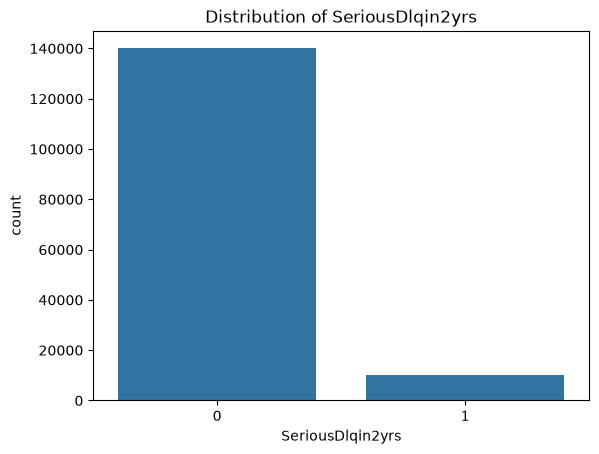

In [7]:
# Percentage of each target label
target_percent = log['SeriousDlqin2yrs'].value_counts(normalize=True) * 100
print(target_percent)

sns.countplot(x='SeriousDlqin2yrs', data=log)
plt.title('Distribution of SeriousDlqin2yrs')
plt.show()

#### Plot the distribution of SeriousDlqin2yrs by age

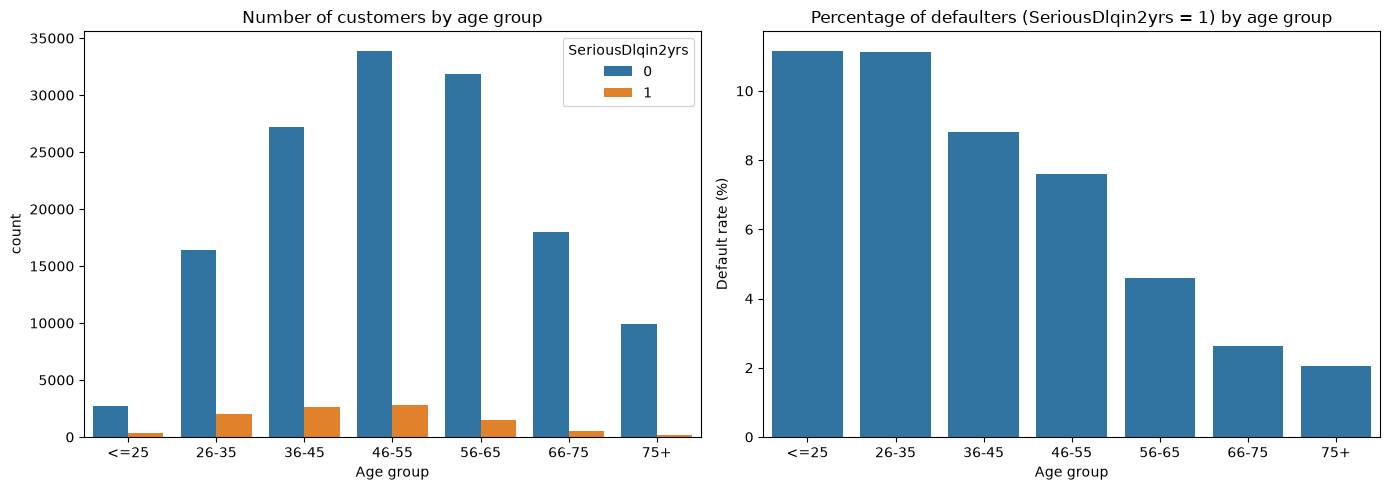

In [8]:
# Group the age into bands (the log dataframe itself is not changed)
age_group = pd.cut(log['age'], bins=[0, 25, 35, 45, 55, 65, 75, 110],
                   labels=['<=25', '26-35', '36-45', '46-55', '56-65', '66-75', '75+'],
                   include_lowest=True)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Number of non-defaulters (0) and defaulters (1) in each age group
sns.countplot(x=age_group, hue=log['SeriousDlqin2yrs'], ax=ax[0])
ax[0].set_title('Number of customers by age group')
ax[0].set_xlabel('Age group')

# Percentage of defaulters in each age group
default_rate = log.groupby(age_group, observed=True)['SeriousDlqin2yrs'].mean() * 100
sns.barplot(x=default_rate.index, y=default_rate.values, ax=ax[1])
ax[1].set_title('Percentage of defaulters (SeriousDlqin2yrs = 1) by age group')
ax[1].set_xlabel('Age group')
ax[1].set_ylabel('Default rate (%)')

plt.tight_layout()
plt.show()

#### Calculate the correlation and plot the heatmap

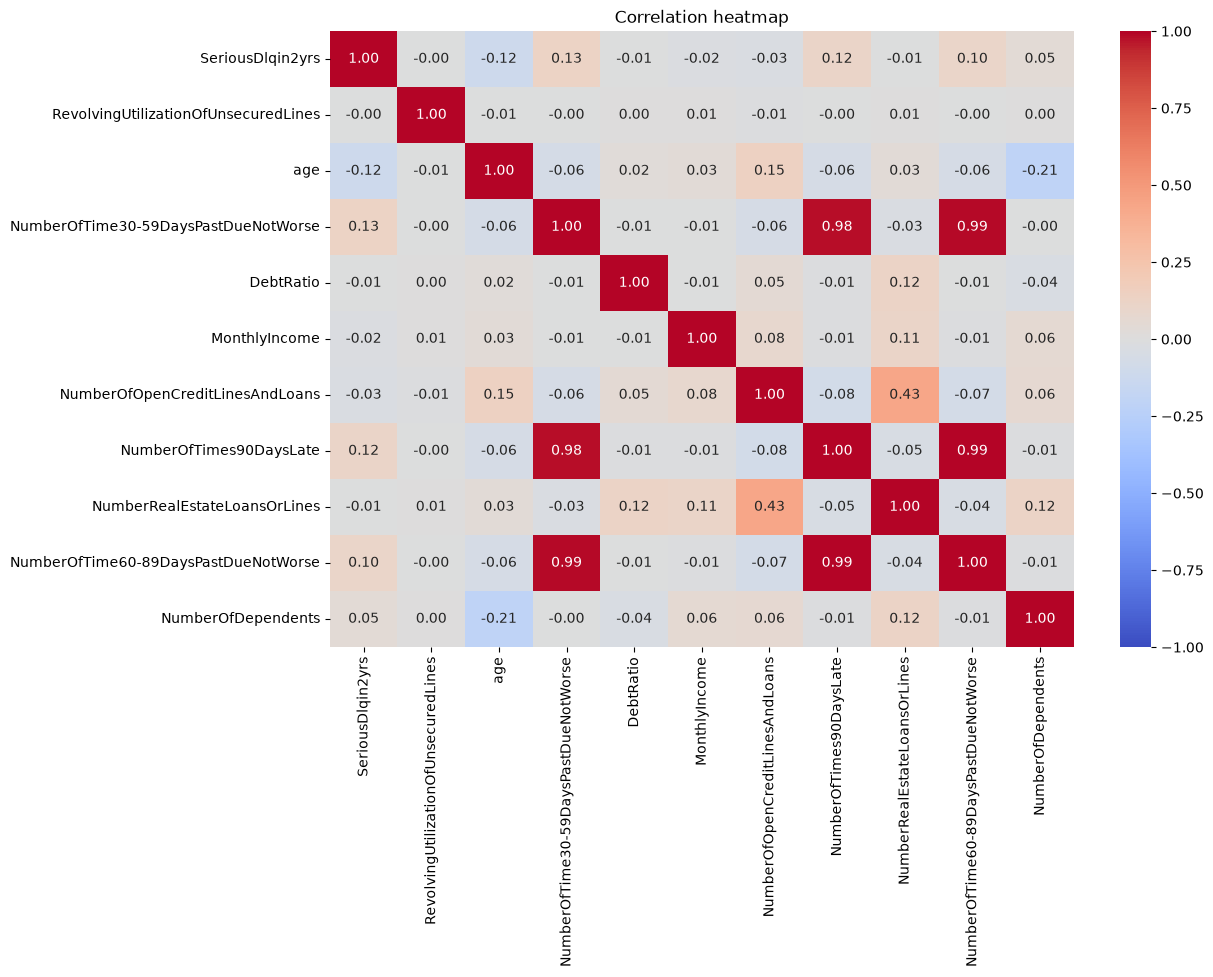

In [9]:
corr = log.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap')
plt.show()

### Data Engineering

#### Weight of Evidence and Information value

* Arrange the binning for each variable with different bins
    * For eg. Age = 49, Age_quantile_range = (48, 56)
* Calculate information value and chooose the best features based on the rules given below

| Information Value |	Variable Predictiveness |
| --- | --- |
| Less than 0.02	|  Not useful for prediction |
| 0.02 to 0.1	| Weak predictive Power |
|  0.1 to 0.3 | Medium predictive Power |
| 0.3 to 0.5 | Strong predictive Power |
| >0.5 | Suspicious Predictive Power |

* Calculate Weight of evidence for the selected variables

Hint: Use [xverse](https://towardsdatascience.com/introducing-xverse-a-python-package-for-feature-selection-and-transformation-17193cdcd067). It is a machine learning Python module in the space of feature engineering, feature transformation and feature selection. It provides pre-built functions for the above steps, such as binning and conversion to WoE.

In [10]:
# Features and target
features = log.drop('SeriousDlqin2yrs', axis=1)
target = log['SeriousDlqin2yrs']

total_events = target.sum()                      # defaulters (bad customers)
total_non_events = len(target) - total_events    # non-defaulters (good customers)

woe_all = pd.DataFrame()   # WOE transformed values of every variable
iv_values = {}             # information value of every variable

for col in features.columns:
    # Step 1: split the variable into (up to) 10 quantile bins
    bins = pd.qcut(features[col], q=10, duplicates='drop')

    # Count variables (e.g. number of times 90 days late) are mostly 0, so quantile
    # bins collapse. For these use the values 0, 1, 2 and 3 or more as the bins
    if bins.nunique() < 4:
        bins = features[col].clip(upper=3)

    # Step 2: events and non-events in each bin
    table = pd.DataFrame({'bin': bins, 'target': target})
    table = table.groupby('bin', observed=True)['target'].agg(['count', 'sum'])
    events = table['sum']
    non_events = table['count'] - table['sum']

    # Step 3: % of events and non-events (0.5 avoids log(0) for empty groups)
    pct_events = events.replace(0, 0.5) / total_events
    pct_non_events = non_events.replace(0, 0.5) / total_non_events

    # Step 4: WOE and IV
    woe = np.log(pct_non_events / pct_events)
    iv_values[col] = ((pct_non_events - pct_events) * woe).sum()

    # Replace every value by the WOE of its bin
    woe_all[col] = bins.map(woe).astype(float)

# Information value table with the predictiveness rule
iv_df = pd.DataFrame({'Variable': list(iv_values.keys()), 'IV': list(iv_values.values())})
iv_df['Predictiveness'] = pd.cut(iv_df['IV'],
                                 bins=[-np.inf, 0.02, 0.1, 0.3, 0.5, np.inf],
                                 labels=['Not useful', 'Weak', 'Medium', 'Strong', 'Suspicious'])
iv_df = iv_df.sort_values('IV', ascending=False).reset_index(drop=True)
print(iv_df)

# Select the variables that are useful for prediction (IV >= 0.02)
selected_features = iv_df[iv_df['IV'] >= 0.02]['Variable'].tolist()
print("\nSelected features:", selected_features)

# WOE values of the selected variables
woe_selected = woe_all[selected_features]
woe_selected.head()

                               Variable        IV Predictiveness
0  RevolvingUtilizationOfUnsecuredLines  1.113378     Suspicious
1               NumberOfTimes90DaysLate  0.877440     Suspicious
2  NumberOfTime30-59DaysPastDueNotWorse  0.755188     Suspicious
3  NumberOfTime60-89DaysPastDueNotWorse  0.600050     Suspicious
4                                   age  0.259158         Medium
5                         MonthlyIncome  0.073688           Weak
6                             DebtRatio  0.073666           Weak
7       NumberOfOpenCreditLinesAndLoans  0.066892           Weak
8          NumberRealEstateLoansOrLines  0.055354           Weak
9                    NumberOfDependents  0.033818           Weak

Selected features: ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'age', 'MonthlyIncome', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDepe

,RevolvingUtilizationOfUnsecuredLines,NumberOfTimes90DaysLate,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,age,MonthlyIncome,DebtRatio,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents
0,-1.021066,0.389724,-1.616726,0.288208,-0.212874,0.359038,-0.578981,0.041544,-0.253629,-0.209307
1,-1.021066,0.389724,0.541721,0.288208,-0.277843,-0.412739,-0.021601,0.046423,-0.235970,-0.102578
2,-0.297972,-1.957968,-0.903654,0.288208,-0.392075,-0.412739,-0.021601,-0.514826,-0.235970,0.150060
3,0.688430,0.389724,0.541721,0.288208,-0.581293,-0.412739,-0.021601,0.057593,-0.235970,0.150060
4,-1.021066,0.389724,-0.903654,0.288208,-0.152829,0.422320,0.230906,0.258194,0.256641,0.150060


### Identify features,  target and split it into train and test

In [11]:
# Features (WOE transformed) and target
X = woe_selected
y = target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
print(X_train.shape, X_test.shape)

(120000, 10) (30000, 10)


### Logistic Regression from scratch using gradient method

For Linear Regression, we had the hypothesis $yhat = w.X +b$ , whose output range was the set of all Real Numbers.
Now, for Logistic Regression our hypothesis is  $yhat = sigmoid(w.X + b)$ , whose output range is between 0 and 1 because by applying a sigmoid function, we always output a number between 0 and 1.

$yhat = \frac{1}{1 +e^{-(w.x+b)}}$

Hint: [logistic-regression-with-python](
https://medium.com/@ODSC/logistic-regression-with-python-ede39f8573c7)

In [12]:
# Gradient descent for logistic regression
X_tr = X_train.values
y_tr = y_train.values
m, n_features = X_tr.shape

w = np.zeros(n_features)
b = 0
learning_rate = 0.1
iterations = 1000

for i in range(iterations):
    z = np.dot(X_tr, w) + b
    yhat = 1 / (1 + np.exp(-z))               # sigmoid

    dw = np.dot(X_tr.T, (yhat - y_tr)) / m    # gradients of the log loss
    db = np.sum(yhat - y_tr) / m

    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 200 == 0:
        loss = -np.mean(y_tr * np.log(yhat + 1e-15) + (1 - y_tr) * np.log(1 - yhat + 1e-15))
        print("Iteration", i, "loss", round(loss, 4))

# Predict on the test data
z_test = np.dot(X_test.values, w) + b
prob_test = 1 / (1 + np.exp(-z_test))
y_pred_scratch = (prob_test >= 0.5).astype(int)

print("Weights:", w)
print("Bias:", b)
print("Accuracy (from scratch):", metrics.accuracy_score(y_test, y_pred_scratch))

Iteration 0 loss 0.6931
Iteration 200 loss 0.1914
Iteration 400 loss 0.1844
Iteration 600 loss 0.1834
Iteration 800 loss 0.1831
Weights: [-0.63496321 -0.51343626 -0.53515501 -0.36950234 -0.32070328 -0.12533744
 -0.26997821 -0.02888185 -0.11832443 -0.06771045]
Bias: -2.5840534592015634
Accuracy (from scratch): 0.9359333333333333


### Implement the Logistic regression using sklearn

As there is imbalance in the class distribution, add weightage to the Logistic regression.

* Find the accuracy with class weightage in Logistic regression
* Find the accuracy without class weightage in Logistic regression

Hint: [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [13]:
# With weightage
model_weighted = LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=1000)
model_weighted.fit(X_train, y_train)

y_pred_weighted = model_weighted.predict(X_test)
print("Accuracy with class weightage:", metrics.accuracy_score(y_test, y_pred_weighted))

Accuracy with class weightage: 0.8044


In [14]:
# Without weightage
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy without class weightage:", metrics.accuracy_score(y_test, y_pred))

Accuracy without class weightage: 0.9355333333333333


### Credit scoring

When scaling the model into a scorecard, we will need both the Logistic Regression coefficients from model fitting as well as the transformed WoE values. We will also need to convert the score from the model from the log-odds unit to a points system.
For each independent variable Xi, its corresponding score is:

$Score = \sum_{i=1}^{n} (-(β_i × WoE_i + \frac{α}{n}) × Factor + \frac{Offset}{n})$

Where:

βi — logistic regression coefficient for the variable Xi

α — logistic regression intercept

WoE — Weight of Evidence value for variable Xi

n — number of independent variable Xi in the model

Factor, Offset — known as scaling parameter

  - Factor = pdo / ln(2); pdo is points to double the odds
  - Offset = Round_of_Score - {Factor * ln(Odds)}

In [15]:
# Scaling factors
factor = 20/np.log(2)
offset = 600 - ( factor * np.log(50))
factor, offset

(np.float64(28.85390081777927), np.float64(487.1228762045055))

In [16]:
# Credit score of every customer using the model with class weightage
n = X.shape[1]                      # number of variables in the model
alpha = model_weighted.intercept_[0]
betas = model_weighted.coef_[0]

score_df = pd.DataFrame()
for i, col in enumerate(X.columns):
    # Points for each variable
    score_df[col] = -(betas[i] * X[col] + alpha / n) * factor + offset / n

score_df['Credit_Score'] = score_df.sum(axis=1)
score_df.head()

,RevolvingUtilizationOfUnsecuredLines,NumberOfTimes90DaysLate,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,age,MonthlyIncome,DebtRatio,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,Credit_Score
0,29.567608,55.444938,18.503622,53.094678,45.946063,49.845377,33.405239,48.697937,44.227012,47.186616,425.919088
1,29.567608,55.444938,58.732269,53.094678,45.125166,47.245297,48.067555,48.705235,44.533976,47.925574,478.442297
2,43.071236,14.426747,31.793701,53.094678,43.681810,47.245297,48.067555,47.865716,44.533976,49.674769,423.455486
3,61.492070,55.444938,58.732269,53.094678,41.290988,47.245297,48.067555,48.721943,44.533976,49.674769,508.298483
4,29.567608,55.444938,31.793701,53.094678,46.704757,50.058573,54.709948,49.022004,53.096936,49.674769,473.167913


### Performance Metrics

#### Precision

In [17]:
print("Precision (with weightage):", metrics.precision_score(y_test, y_pred_weighted))
print("Precision (without weightage):", metrics.precision_score(y_test, y_pred))

Precision (with weightage): 0.2182112862825991
Precision (without weightage): 0.5869218500797448


#### Recall

In [18]:
print("Recall (with weightage):", metrics.recall_score(y_test, y_pred_weighted))
print("Recall (without weightage):", metrics.recall_score(y_test, y_pred))

Recall (with weightage): 0.7249143416544298
Recall (without weightage): 0.18012726382770436


#### Classification Report

In [19]:
print("With weightage")
print(metrics.classification_report(y_test, y_pred_weighted))

print("Without weightage")
print(metrics.classification_report(y_test, y_pred))

With weightage
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     27957
           1       0.22      0.72      0.34      2043

    accuracy                           0.80     30000
   macro avg       0.60      0.77      0.61     30000
weighted avg       0.92      0.80      0.85     30000

Without weightage
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27957
           1       0.59      0.18      0.28      2043

    accuracy                           0.94     30000
   macro avg       0.76      0.59      0.62     30000
weighted avg       0.92      0.94      0.92     30000



#### Confusion matrix

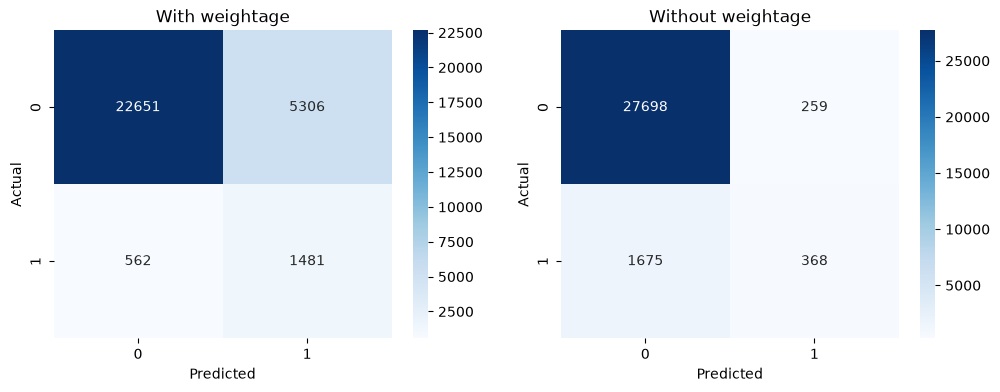

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(metrics.confusion_matrix(y_test, y_pred_weighted), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('With weightage')

sns.heatmap(metrics.confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Without weightage')

for a in ax:
    a.set_xlabel('Predicted')
    a.set_ylabel('Actual')
plt.show()

### Report Analysis

* Comment on the performance of the model with weightage and without weightage
* Have you tried implementing Logistic regression with normal features instead of WOE ?
  - Compare the classification report for both implementations

**1. Performance with and without class weightage** (WOE features, 80/20 split, `random_state=0`)

| Model | Accuracy | Precision (defaulters) | Recall (defaulters) | F1 (defaulters) |
|---|---|---|---|---|
| Without weightage | 0.936 | 0.587 | 0.180 | 0.276 |
| With weightage | 0.804 | 0.218 | 0.725 | 0.335 |

* Only about 6.7% of the customers are defaulters, so a model that predicts "no default" for everyone already has about 93.2% accuracy. The 93.6% accuracy without weightage is therefore misleading: the model catches only 368 of the 2,043 defaulters in the test data (recall 0.18) and misses the other 1,675.
* With class weightage the model gives the defaulter class more importance. Accuracy falls to 80%, but it catches 1,481 of the 2,043 defaulters (recall 0.72). The cost is more false alarms: 5,306 good customers are wrongly flagged, which is why precision drops to 0.22.
* For credit risk, approving a customer who later defaults is usually more costly than rejecting a good one, so the weighted model is the more useful one, even though its accuracy is lower. Accuracy is not a suitable metric for imbalanced data; recall, F1 and ROC AUC should be used.
* The ROC AUC is almost the same for both models (0.849 and 0.851). Weightage does not make the model rank customers better; it only moves the decision threshold so that more customers are labelled as defaulters.

**2. WOE features vs normal features** (class weightage and no weightage, same split)

| Model | Accuracy | Recall (defaulters) | F1 (defaulters) | ROC AUC |
|---|---|---|---|---|
| WOE, without weightage | 0.936 | 0.180 | 0.276 | 0.849 |
| Normal, without weightage | 0.933 | 0.046 | 0.085 | 0.693 |
| WOE, with weightage | 0.804 | 0.725 | 0.335 | 0.851 |
| Normal, with weightage | 0.767 | 0.633 | 0.270 | 0.784 |

* Yes, Logistic Regression was also implemented with the normal (scaled) features. WOE features are better in every comparison. The clearest difference is the ROC AUC (0.85 vs 0.69 without weightage, 0.85 vs 0.78 with weightage), which does not depend on the threshold.
* Without weightage, the normal-feature model finds only 4.6% of the defaulters (recall 0.046), compared with 18% for the WOE model.
* With weightage, the WOE model has better recall (0.72 vs 0.63), better F1 (0.34 vs 0.27) and better accuracy (0.80 vs 0.77).
* Reasons: the normal features contain extreme outliers (for example RevolvingUtilizationOfUnsecuredLines has a mean of about 6 but a maximum of 50,708) and their relationship with default is not linear. Logistic Regression assumes the log-odds change linearly with each feature. WOE binning limits the effect of outliers and converts every variable to a scale where higher WOE means lower risk, so a linear model fits much better. WOE also makes the coefficients easy to interpret and is the base for the credit scorecard.

**3. Comparison of the classification reports for both implementations** (30,000 test records: 27,957 non-defaulters and 2,043 defaulters)

**With weightage**

| Metric | WOE features | Normal features |
|---|---|---|
| Precision (class 0) | 0.98 | 0.97 |
| Recall (class 0) | 0.81 | 0.78 |
| F1-score (class 0) | 0.89 | 0.86 |
| Precision (class 1) | 0.22 | 0.17 |
| Recall (class 1) | 0.72 | 0.63 |
| F1-score (class 1) | 0.34 | 0.27 |
| Accuracy | 0.80 | 0.77 |
| Macro avg F1-score | 0.61 | 0.57 |

**Without weightage**

| Metric | WOE features | Normal features |
|---|---|---|
| Precision (class 0) | 0.94 | 0.93 |
| Recall (class 0) | 0.99 | 1.00 |
| F1-score (class 0) | 0.97 | 0.97 |
| Precision (class 1) | 0.59 | 0.62 |
| Recall (class 1) | 0.18 | 0.05 |
| F1-score (class 1) | 0.28 | 0.08 |
| Accuracy | 0.94 | 0.93 |
| Macro avg F1-score | 0.62 | 0.53 |

* With weightage, the WOE model is better on every metric. It identifies 72% of the defaulters, compared with 63% for the normal-feature model. Its F1-score for defaulters is 0.34 vs 0.27, and its accuracy is 0.80 vs 0.77.
* Without weightage, both models predict almost every customer as a non-defaulter, so class 0 looks excellent (recall 0.99 to 1.00) while class 1 is poor. The normal-feature model is much weaker here. It finds only 5% of the defaulters (F1-score 0.08), compared with 18% (F1-score 0.28) for the WOE model.
* The normal-feature model's slightly higher precision for class 1 without weightage (0.62 vs 0.59) is not a real advantage, because it predicts defaulters for only a tiny number of customers.
* The accuracy of both models without weightage (0.93 to 0.94) is high only because 93% of the customers are non-defaulters. The macro average F1-score (0.62 vs 0.53) and the class 1 scores show the real difference between the two implementations.
* Overall, Logistic Regression with WOE features performs better than with normal features, and the class-weighted WOE model is the best choice for identifying defaulters.